# 🎬 IMDB Top 250 Movies — Data Science 
**EDA · Statistical Analysis · ML Rating Prediction · Trend Forecasting**

> Dataset: [IMDb Top 250 Movies of All Time (1921–2025)](https://www.kaggle.com/datasets/shauryasrivastava01/imdb-top-250-movies-of-all-time-19212025) — Kaggle

---
## Table of Contents
1. [Setup & Dataset Download](#1-setup)
2. [Load & Clean Data](#2-load)
3. [Exploratory Data Analysis (EDA)](#3-eda)
4. [Genre & Decade Deep-Dive](#4-genre)
5. [Statistical Analysis](#5-stats)
6. [Machine Learning: Predict IMDb Rating](#6-ml)
7. [Trend Forecasting](#7-forecast)
8. [Key Insights Summary](#8-insights)


## 1. Setup & Dataset Download <a id='1-setup'></a>

In [1]:
# Install dependencies if needed
# !pip install kagglehub pandas numpy matplotlib seaborn scikit-learn scipy

import warnings, os, re
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib.pyplot   as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker   as mticker
import matplotlib.patches  as mpatches
import seaborn             as sns
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.linear_model    import LinearRegression, Ridge
from sklearn.ensemble        import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics         import mean_absolute_error, r2_score, mean_squared_error

# Notebook-friendly inline plots
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

np.random.seed(42)
print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


### Download via KaggleHub
Run the cell below once. After it prints the path, set `CSV_PATH` in the next cell.


In [2]:
import kagglehub

path = kagglehub.dataset_download(
    'shauryasrivastava01/imdb-top-250-movies-of-all-time-19212025'
)
print('Dataset downloaded to:', path)

# List files in the downloaded folder
for f in os.listdir(path):
    print(' -', f)

Dataset downloaded to: /Users/colecoli/.cache/kagglehub/datasets/shauryasrivastava01/imdb-top-250-movies-of-all-time-19212025/versions/1
 - movies.csv


In [3]:
# ▶ UPDATE THIS PATH to the .csv file shown above
CSV_PATH = os.path.join(path, 'imdb_top_250.csv')  # adjust filename if needed

# Theme constants
DARK_BG  = '#0F1117'
CARD_BG  = '#1A1D27'
ACCENT   = '#F5C518'   # IMDb gold

print(f'CSV_PATH set to: {CSV_PATH}')

CSV_PATH set to: /Users/colecoli/.cache/kagglehub/datasets/shauryasrivastava01/imdb-top-250-movies-of-all-time-19212025/versions/1/imdb_top_250.csv


## 2. Load & Clean Data <a id='2-load'></a>

In [4]:
def load_and_clean(path: str) -> pd.DataFrame:
    """
    Loads the IMDB Top-250 CSV and normalises column names,
    data types, runtime format, and derives helper columns.
    Falls back to synthetic data if file not found.
    """
    if not os.path.exists(path):
        print('⚠  File not found — generating synthetic demo data.')
        return _make_synthetic()

    df = pd.read_csv(path)

    # Normalise column names
    df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]
    rename_map = {
        'imdb_rating': 'rating', 'imdb_score': 'rating',
        'num_votes':   'votes',  'vote_count': 'votes',
        'duration':    'runtime','movie_title': 'title',
    }
    df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns}, inplace=True)

    # Numeric coercion
    for col in ['rating', 'metascore', 'votes', 'year', 'rank']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # Runtime → integer minutes
    if 'runtime' in df.columns:
        df['runtime'] = df['runtime'].astype(str).str.extract(r'(\d+)')[0].astype(float)

    # Derived columns
    if 'year' in df.columns:
        df['decade'] = (df['year'] // 10 * 10).astype('Int64')
    if 'genre' in df.columns:
        df['primary_genre'] = df['genre'].astype(str).str.split(r'[,|/]').str[0].str.strip()

    df.dropna(subset=['rating'], inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df


def _make_synthetic() -> pd.DataFrame:
    """Realistic synthetic IMDB Top-250 fallback dataset."""
    genres = ['Drama','Crime','Action','Adventure','Comedy',
              'Biography','Animation','Thriller','Sci-Fi','War']
    directors = [
        'Christopher Nolan','Stanley Kubrick','Francis Ford Coppola',
        'Steven Spielberg','Martin Scorsese','Sergio Leone',
        'Akira Kurosawa','Peter Jackson','Ridley Scott','David Fincher',
        'Alfred Hitchcock','Billy Wilder','Clint Eastwood','Quentin Tarantino',
        'James Cameron','Frank Darabont','Hayao Miyazaki','Robert Zemeckis',
    ]
    n = 250
    years    = np.random.choice(list(range(1921,1960,3)) + list(range(1960,1990,2)) + list(range(1990,2025)), size=n)
    ratings  = np.clip(np.random.normal(8.25, 0.22, n), 8.0, 9.3).round(1)
    votes    = np.clip((np.random.lognormal(13.0, 0.9, n)).astype(int), 25_000, 2_800_000)
    runtimes = np.clip(np.random.normal(130, 25, n), 65, 238).astype(int)
    meta     = np.clip(np.random.normal(82, 9, n), 55, 100).astype(int)
    genre_v  = np.random.choice(genres, n, p=[.28,.15,.10,.08,.09,.07,.06,.06,.06,.05])
    return pd.DataFrame({
        'rank': range(1, n+1),
        'title': [f'Movie #{i}' for i in range(1, n+1)],
        'year': years, 'rating': ratings, 'votes': votes,
        'runtime': runtimes, 'metascore': meta,
        'genre': genre_v, 'primary_genre': genre_v,
        'director': np.random.choice(directors, n),
        'decade': (years // 10 * 10),
    })


df = load_and_clean(CSV_PATH)
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')

⚠  File not found — generating synthetic demo data.
Shape: (250, 11)
Columns: ['rank', 'title', 'year', 'rating', 'votes', 'runtime', 'metascore', 'genre', 'primary_genre', 'director', 'decade']


In [5]:
# Quick preview
df.head(10)

,rank,title,year,rating,votes,runtime,metascore,genre,primary_genre,director,decade
0,1,Movie #1,2000,8.0,239400,154,86,Action,Action,Clint Eastwood,2000
1,2,Movie #2,2013,8.3,423633,154,91,Thriller,Thriller,Stanley Kubrick,2010
2,3,Movie #3,1990,8.2,1388902,164,74,Drama,Drama,Peter Jackson,1990
3,4,Movie #4,1962,8.2,885384,155,82,Comedy,Comedy,Stanley Kubrick,1960
4,5,Movie #5,2004,8.3,689290,89,66,Thriller,Thriller,Steven Spielberg,2000
5,6,Movie #6,1942,8.2,479253,137,70,Sci-Fi,Sci-Fi,James Cameron,1940
6,7,Movie #7,2022,8.3,120445,103,89,Comedy,Comedy,Steven Spielberg,2020
7,8,Movie #8,1974,8.0,206959,117,73,Action,Action,Clint Eastwood,1970
8,9,Movie #9,2000,8.0,324850,134,74,Comedy,Comedy,Billy Wilder,2000
9,10,Movie #10,2019,8.6,667910,150,81,Thriller,Thriller,Clint Eastwood,2010


In [6]:
# Data types & missing values
info = pd.DataFrame({
    'dtype':    df.dtypes,
    'non_null': df.notnull().sum(),
    'missing':  df.isnull().sum(),
    'missing%': (df.isnull().mean() * 100).round(1),
})
info

,dtype,non_null,missing,missing%
rank,int64,250,0,0.0
title,str,250,0,0.0
year,int64,250,0,0.0
rating,float64,250,0,0.0
votes,int64,250,0,0.0
runtime,int64,250,0,0.0
metascore,int64,250,0,0.0
genre,str,250,0,0.0
primary_genre,str,250,0,0.0
director,str,250,0,0.0


In [7]:
# Descriptive statistics
df.describe().round(3)

,rank,year,rating,votes,runtime,metascore,decade
count,250.000,250.000,250.000,250.000,250.000,250.000,250.000
mean,125.500,1986.812,8.289,642361.156,127.748,81.672,1982.920
std,72.313,29.429,0.202,594875.439,26.264,8.236,29.437
min,1.000,1921.000,8.000,37539.000,65.000,55.000,1920.000
25%,63.250,1966.000,8.100,260861.250,109.250,76.000,1960.000
50%,125.500,1994.500,8.300,440526.500,128.000,82.000,1990.000
75%,187.750,2011.000,8.400,865806.500,145.000,87.000,2010.000
max,250.000,2024.000,8.900,2800000.000,196.000,100.000,2020.000


### Helper: Dark-theme axis styler

In [8]:
def style_ax(ax, title='', xlabel='', ylabel=''):
    ax.set_facecolor(CARD_BG)
    ax.tick_params(colors='white', labelsize=8)
    ax.spines[:].set_color('#3A3D4A')
    if title:  ax.set_title(title,  color='white', fontsize=10, fontweight='bold', pad=7)
    if xlabel: ax.set_xlabel(xlabel, color='#AAAAAA', fontsize=8)
    if ylabel: ax.set_ylabel(ylabel, color='#AAAAAA', fontsize=8)

## 3. Exploratory Data Analysis (EDA) <a id='3-eda'></a>

### 3.1 Rating Distribution

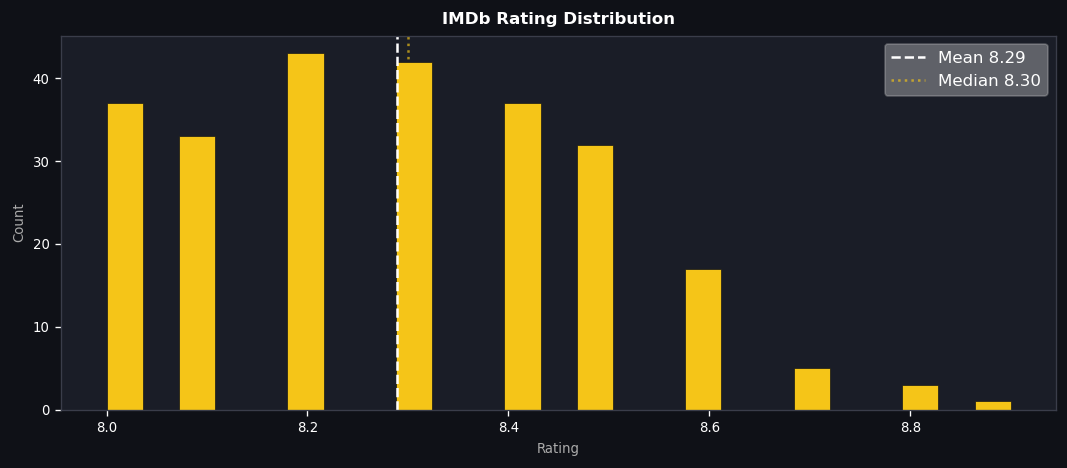

Skewness: 0.338  |  Kurtosis: -0.514


In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor(DARK_BG)
style_ax(ax, 'IMDb Rating Distribution', 'Rating', 'Count')
ax.hist(df['rating'], bins=25, color=ACCENT, edgecolor=DARK_BG, linewidth=0.4)
ax.axvline(df['rating'].mean(),   color='white',      ls='--', lw=1.5, label=f"Mean {df['rating'].mean():.2f}")
ax.axvline(df['rating'].median(), color='#F5C518AA',  ls=':',  lw=1.5, label=f"Median {df['rating'].median():.2f}")
ax.legend(framealpha=0.3, labelcolor='white')
plt.tight_layout()
plt.show()
print(f"Skewness: {df['rating'].skew():.3f}  |  Kurtosis: {df['rating'].kurt():.3f}")

### 3.2 Movies per Decade

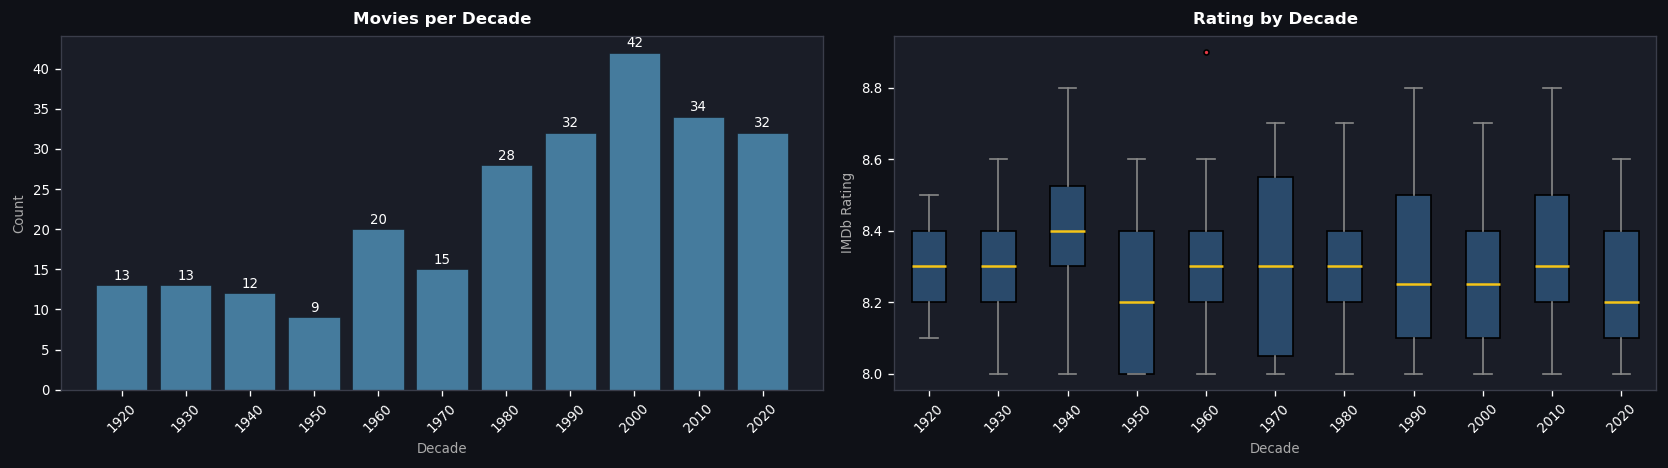

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.patch.set_facecolor(DARK_BG)

# Bar: count per decade
ax = axes[0]
style_ax(ax, 'Movies per Decade', 'Decade', 'Count')
dc = df['decade'].value_counts().sort_index()
bars = ax.bar(dc.index.astype(str), dc.values, color='#457B9D', edgecolor=DARK_BG, linewidth=0.3)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(int(bar.get_height())), ha='center', va='bottom', color='white', fontsize=8)
ax.tick_params(axis='x', rotation=45)

# Box: rating spread per decade
ax = axes[1]
style_ax(ax, 'Rating by Decade', 'Decade', 'IMDb Rating')
decades_sorted = sorted(df['decade'].dropna().unique())
data_by_decade = [df[df['decade'] == d]['rating'].dropna() for d in decades_sorted]
bp = ax.boxplot(data_by_decade, patch_artist=True,
                medianprops=dict(color=ACCENT, lw=1.5),
                whiskerprops=dict(color='#888'), capprops=dict(color='#888'),
                flierprops=dict(markerfacecolor='#E63946', markersize=3))
for patch in bp['boxes']:
    patch.set_facecolor('#2A4A6B')
ax.set_xticklabels([str(d) for d in decades_sorted], rotation=45)

plt.tight_layout()
plt.show()

### 3.3 Votes vs. Rating

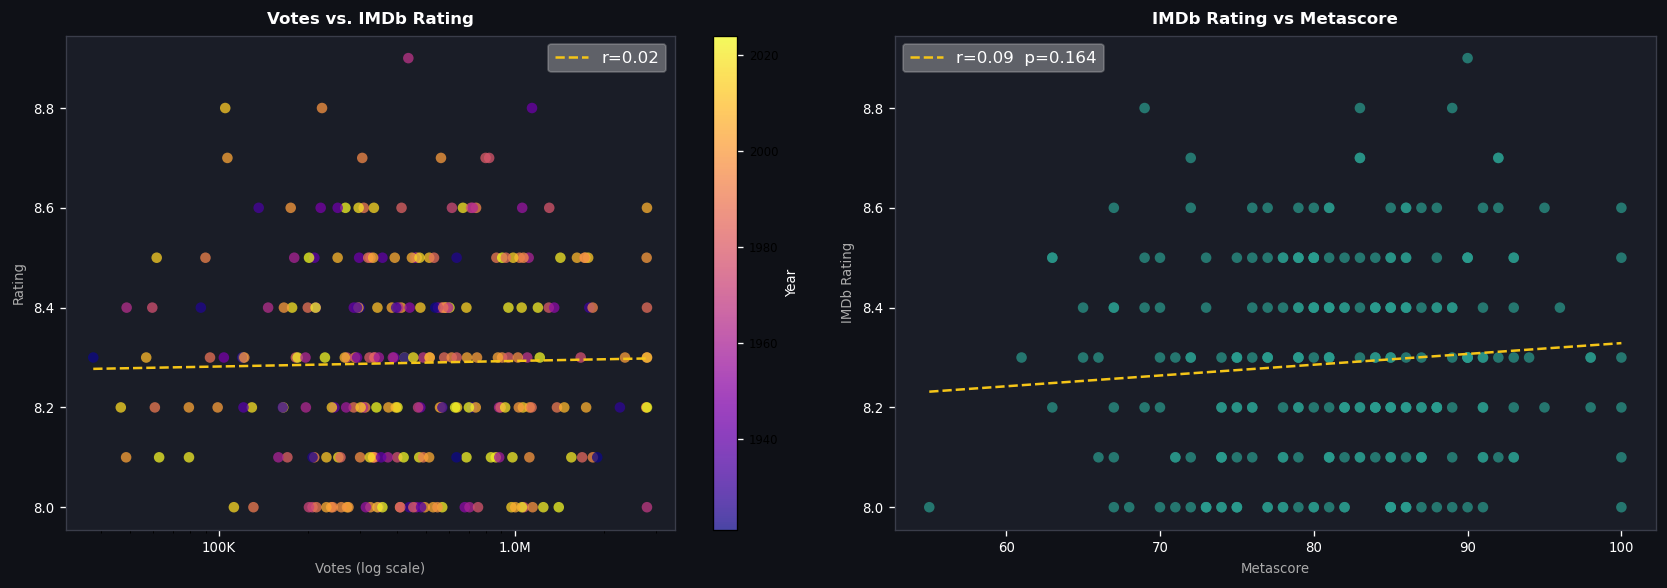

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(DARK_BG)

# Scatter: votes vs rating
ax = axes[0]
style_ax(ax, 'Votes vs. IMDb Rating', 'Votes (log scale)', 'Rating')
if 'votes' in df.columns:
    sc = ax.scatter(df['votes'], df['rating'], c=df['year'], cmap='plasma',
                    alpha=0.75, s=40, edgecolors='none')
    ax.set_xscale('log')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))
    cbar = plt.colorbar(sc, ax=ax)
    cbar.ax.yaxis.set_tick_params(color='white', labelsize=7)
    cbar.set_label('Year', color='white', fontsize=8)
    log_v = np.log10(df['votes'].replace(0, np.nan).dropna())
    rv    = df.loc[log_v.index, 'rating']
    m, b, r, p, _ = stats.linregress(log_v, rv)
    xline = np.linspace(log_v.min(), log_v.max(), 100)
    ax.plot(10**xline, m*xline + b, color=ACCENT, lw=1.5, ls='--', label=f'r={r:.2f}')
    ax.legend(framealpha=0.3, labelcolor='white')

# Scatter: metascore vs rating
ax = axes[1]
style_ax(ax, 'IMDb Rating vs Metascore', 'Metascore', 'IMDb Rating')
if 'metascore' in df.columns:
    valid = df.dropna(subset=['metascore', 'rating'])
    ax.scatter(valid['metascore'], valid['rating'], color='#2A9D8F', alpha=0.7, s=40, edgecolors='none')
    m, b, r, p, _ = stats.linregress(valid['metascore'], valid['rating'])
    xs = np.linspace(valid['metascore'].min(), valid['metascore'].max(), 100)
    ax.plot(xs, m*xs + b, color=ACCENT, lw=1.5, ls='--',
            label=f"r={r:.2f}  p={'<0.001' if p<0.001 else f'{p:.3f}'}")
    ax.legend(framealpha=0.3, labelcolor='white')

plt.tight_layout()
plt.show()

### 3.4 Top Genres & Top Directors

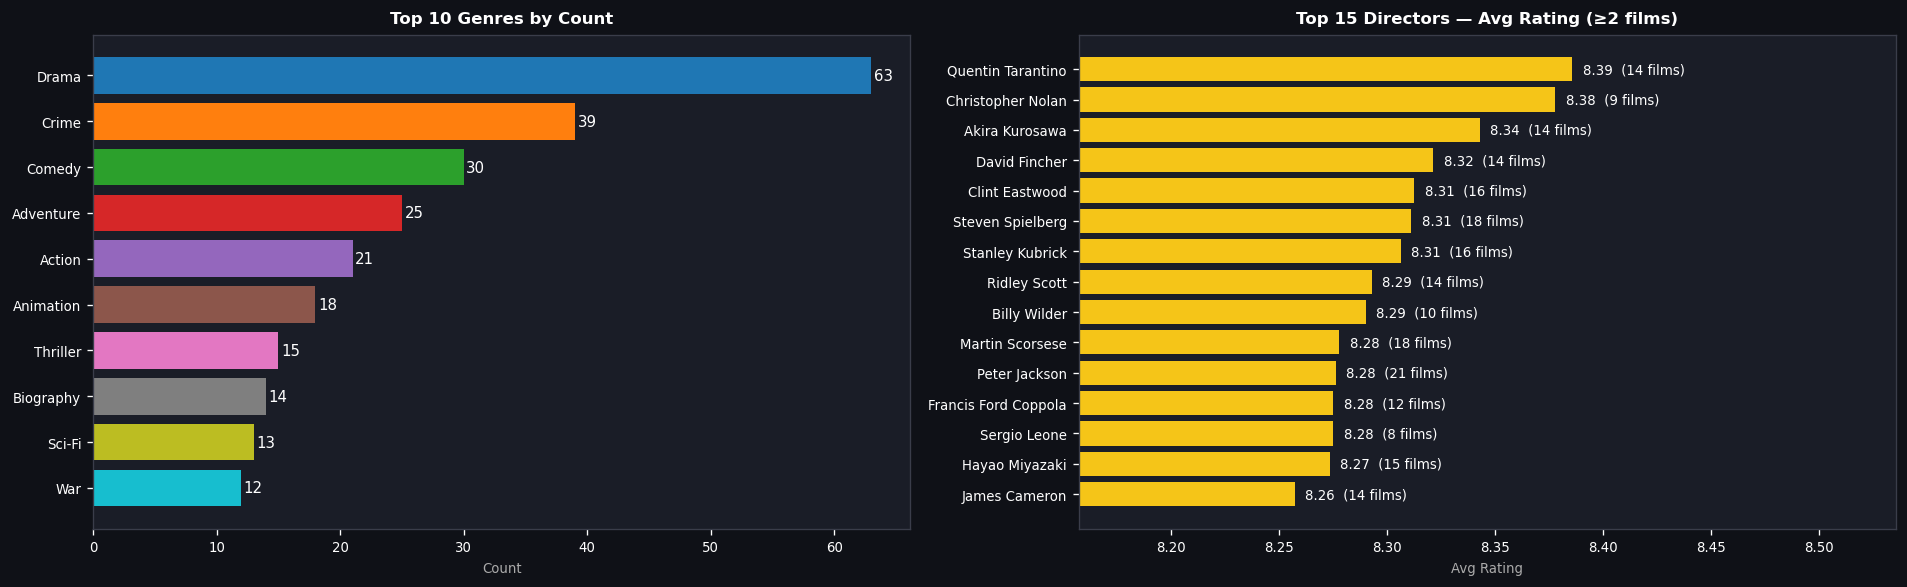

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor(DARK_BG)

# Top genres
ax = axes[0]
style_ax(ax, 'Top 10 Genres by Count', 'Count', '')
if 'primary_genre' in df.columns:
    gc = df['primary_genre'].value_counts().head(10)
    cmap = plt.cm.get_cmap('tab10', len(gc))
    ax.barh(gc.index, gc.values, color=[cmap(i) for i in range(len(gc))], edgecolor='none')
    for i, v in enumerate(gc.values):
        ax.text(v + 0.2, i, str(v), va='center', color='white', fontsize=9)
    ax.invert_yaxis()

# Top directors
ax = axes[1]
style_ax(ax, 'Top 15 Directors — Avg Rating (≥2 films)', 'Avg Rating', '')
if 'director' in df.columns:
    dir_stats = (df.groupby('director')
                   .agg(avg_rating=('rating','mean'), film_count=('rating','count'))
                   .query('film_count >= 2')
                   .sort_values('avg_rating', ascending=True)
                   .tail(15))
    bars = ax.barh(dir_stats.index, dir_stats['avg_rating'], color=ACCENT, edgecolor='none')
    ax.set_xlim(dir_stats['avg_rating'].min() - 0.1, dir_stats['avg_rating'].max() + 0.15)
    for bar, cnt in zip(bars, dir_stats['film_count']):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f"{bar.get_width():.2f}  ({cnt} films)", va='center', color='white', fontsize=8)

plt.tight_layout()
plt.show()

### 3.5 Runtime Distribution

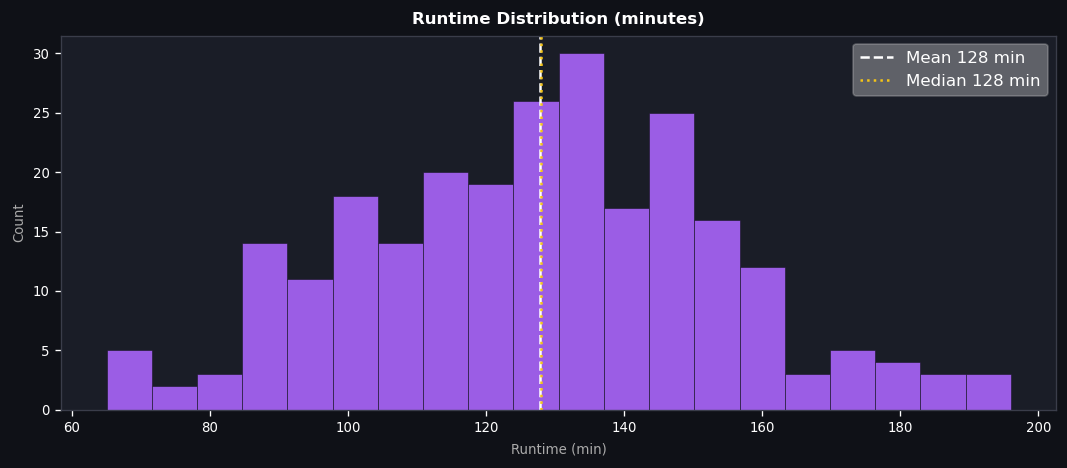

count    250.0
mean     127.7
std       26.3
min       65.0
25%      109.2
50%      128.0
75%      145.0
max      196.0
Name: runtime, dtype: float64


In [13]:
fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor(DARK_BG)
style_ax(ax, 'Runtime Distribution (minutes)', 'Runtime (min)', 'Count')
if 'runtime' in df.columns:
    ax.hist(df['runtime'].dropna(), bins=20, color='#9B5DE5', edgecolor=DARK_BG, linewidth=0.3)
    ax.axvline(df['runtime'].mean(), color='white', ls='--', lw=1.5,
               label=f"Mean {df['runtime'].mean():.0f} min")
    ax.axvline(df['runtime'].median(), color=ACCENT, ls=':', lw=1.5,
               label=f"Median {df['runtime'].median():.0f} min")
    ax.legend(framealpha=0.3, labelcolor='white')
plt.tight_layout()
plt.show()
print(df['runtime'].describe().round(1))

## 4. Genre & Decade Deep-Dive <a id='4-genre'></a>

### 4.1 Avg Rating per Genre + Genre over Decades

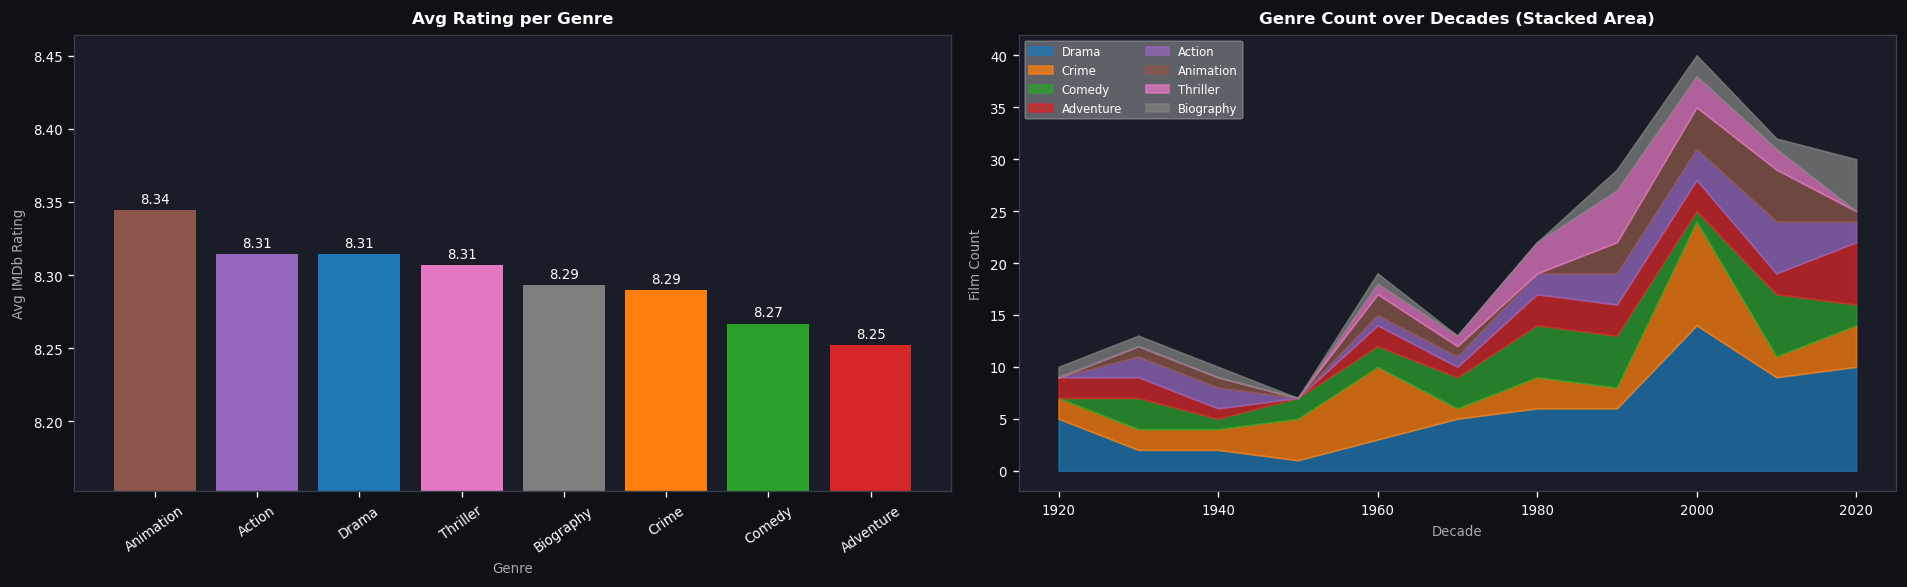

In [14]:
if 'primary_genre' not in df.columns:
    print('No genre column found.')
else:
    top_genres  = df['primary_genre'].value_counts().head(8).index.tolist()
    df_genre    = df[df['primary_genre'].isin(top_genres)].copy()
    palette     = dict(zip(top_genres, sns.color_palette('tab10', len(top_genres))))

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.patch.set_facecolor(DARK_BG)

    # Avg rating per genre
    ax = axes[0]
    style_ax(ax, 'Avg Rating per Genre', 'Genre', 'Avg IMDb Rating')
    gr = df_genre.groupby('primary_genre')['rating'].mean().sort_values(ascending=False)
    ax.bar(gr.index, gr.values, color=[palette[g] for g in gr.index], edgecolor='none')
    ax.set_ylim(gr.min() - 0.1, gr.max() + 0.12)
    ax.tick_params(axis='x', rotation=35)
    for i, (g, v) in enumerate(gr.items()):
        ax.text(i, v + 0.005, f'{v:.2f}', ha='center', color='white', fontsize=8)

    # Genre count over decades (stacked area)
    ax = axes[1]
    style_ax(ax, 'Genre Count over Decades (Stacked Area)', 'Decade', 'Film Count')
    pivot  = df_genre.groupby(['decade','primary_genre']).size().unstack(fill_value=0)
    bottom = np.zeros(len(pivot))
    for genre in top_genres:
        if genre in pivot.columns:
            vals = pivot[genre].values
            ax.fill_between(pivot.index, bottom, bottom + vals,
                            alpha=0.75, label=genre, color=palette[genre])
            bottom += vals
    ax.legend(loc='upper left', framealpha=0.3, labelcolor='white', fontsize=7, ncol=2)

    plt.tight_layout()
    plt.show()

### 4.2 Rating Heatmap: Genre × Decade

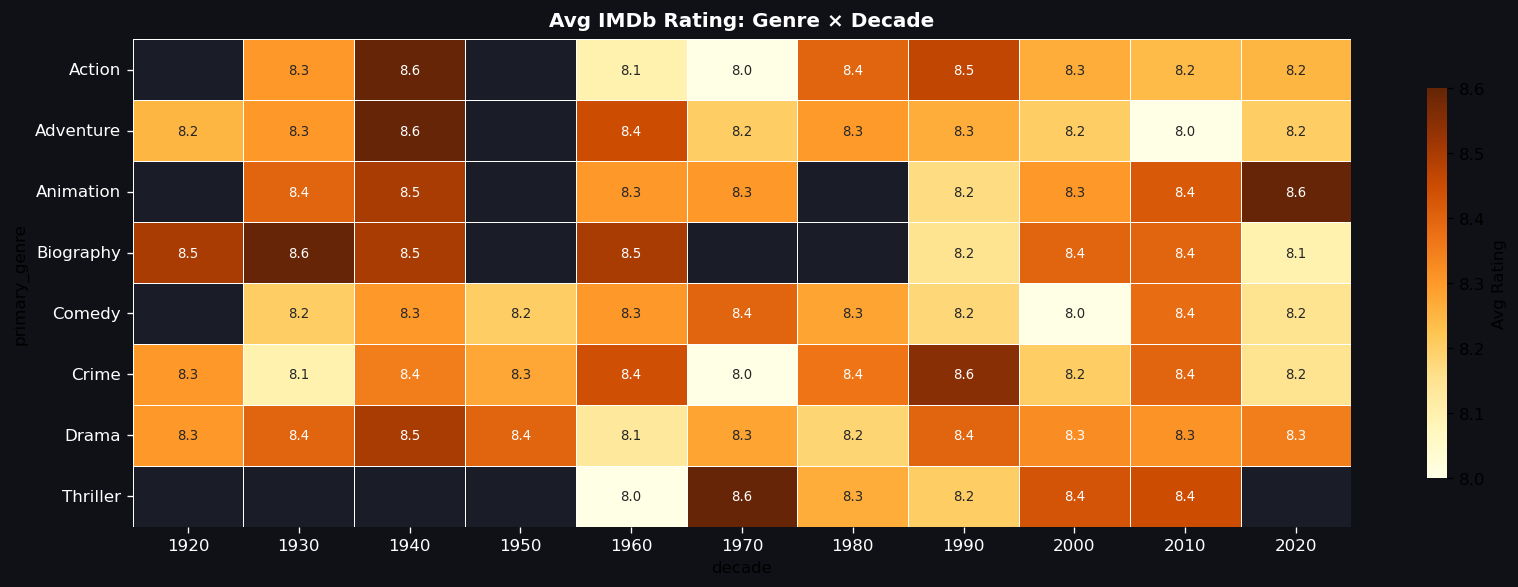

In [15]:
if 'primary_genre' in df.columns:
    heat = (df_genre.groupby(['primary_genre','decade'])['rating']
                    .mean().unstack())
    fig, ax = plt.subplots(figsize=(14, 5))
    fig.patch.set_facecolor(DARK_BG)
    ax.set_facecolor(CARD_BG)
    sns.heatmap(heat, ax=ax, cmap='YlOrBr', linewidths=0.3,
                annot=True, fmt='.1f', annot_kws={'size': 8},
                cbar_kws={'shrink': 0.8, 'label': 'Avg Rating'})
    ax.set_title('Avg IMDb Rating: Genre × Decade', color='white',
                 fontsize=12, fontweight='bold', pad=8)
    ax.tick_params(colors='white')
    plt.tight_layout()
    plt.show()

### 4.3 Top 20 Highest-Rated Films

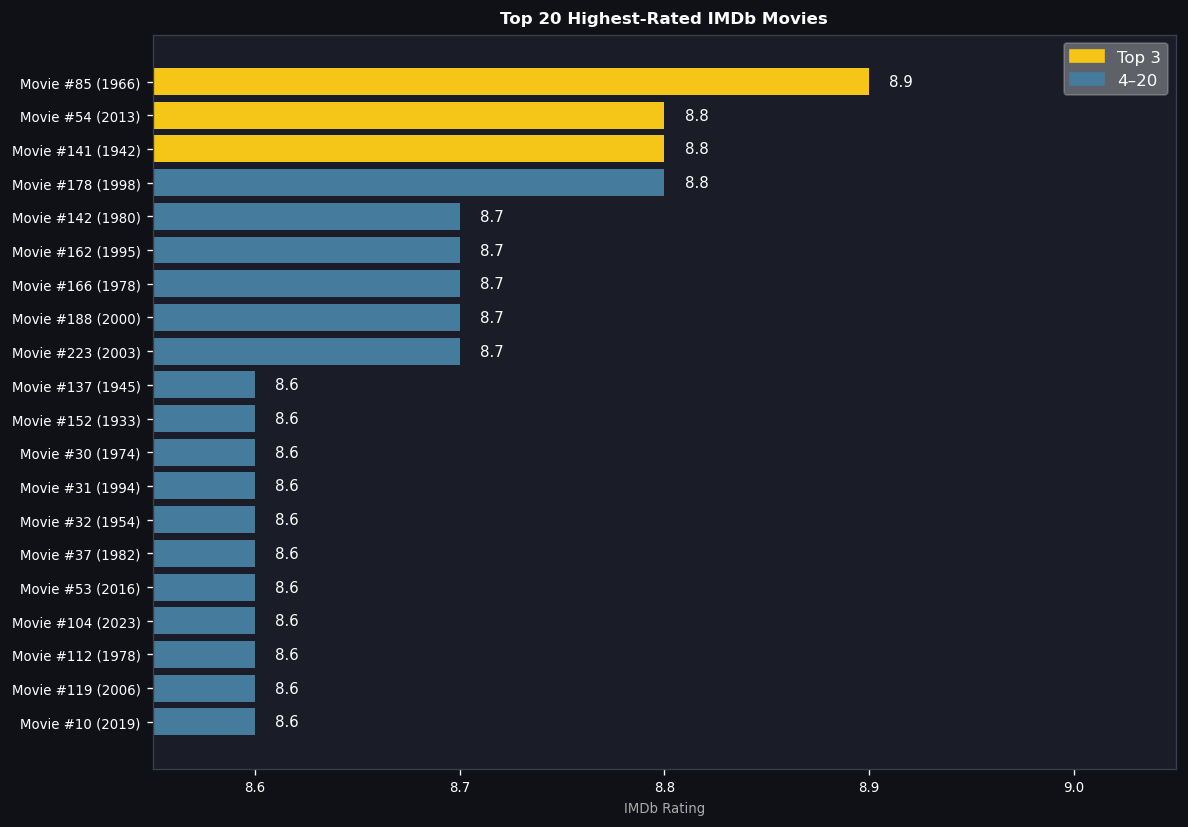

,title,year,rating,primary_genre
0,Movie #85,1966,8.9,Crime
1,Movie #54,2013,8.8,Comedy
2,Movie #141,1942,8.8,Action
3,Movie #178,1998,8.8,Action
4,Movie #142,1980,8.7,War
5,Movie #162,1995,8.7,Drama
6,Movie #166,1978,8.7,Drama
7,Movie #188,2000,8.7,Biography
8,Movie #223,2003,8.7,Thriller
9,Movie #119,2006,8.6,Drama


In [16]:
top20 = df.nlargest(20, 'rating')[['title','year','rating','primary_genre']].copy()
top20 = top20.sort_values('rating')

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(DARK_BG)
style_ax(ax, 'Top 20 Highest-Rated IMDb Movies', 'IMDb Rating', '')

bar_colors = [ACCENT if i >= 17 else '#457B9D' for i in range(len(top20))]
labels = [f"{row['title'][:35]} ({int(row['year'])})" for _, row in top20.iterrows()]
ax.barh(labels, top20['rating'], color=bar_colors, edgecolor='none')
ax.set_xlim(top20['rating'].min() - 0.05, top20['rating'].max() + 0.15)
for i, (_, row) in enumerate(top20.iterrows()):
    ax.text(row['rating'] + 0.01, i, f"{row['rating']:.1f}",
            va='center', color='white', fontsize=9)

gold  = mpatches.Patch(color=ACCENT,    label='Top 3')
blue  = mpatches.Patch(color='#457B9D', label='4–20')
ax.legend(handles=[gold, blue], framealpha=0.3, labelcolor='white')
plt.tight_layout()
plt.show()
top20.sort_values('rating', ascending=False).reset_index(drop=True)

## 5. Statistical Analysis <a id='5-stats'></a>

### 5.1 Normality Check (Q–Q Plot)

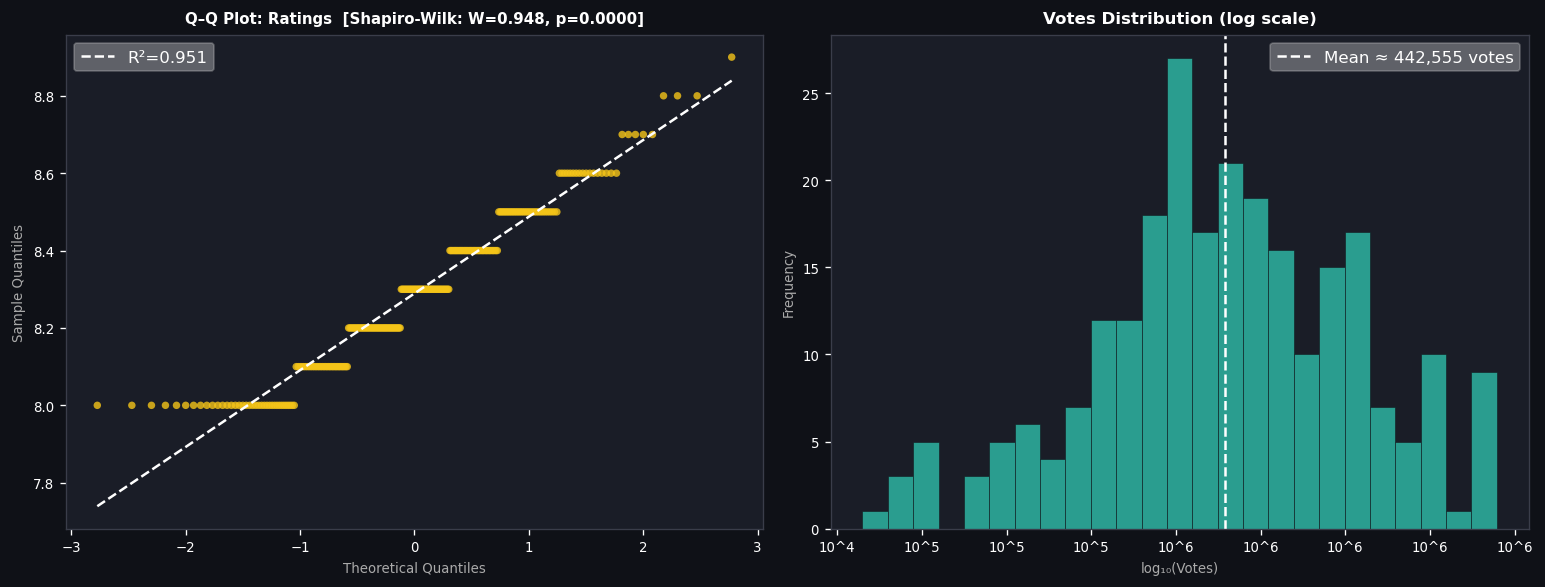

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor(DARK_BG)

# Q-Q plot
ax = axes[0]
style_ax(ax, 'Q–Q Plot: IMDb Ratings vs Normal', 'Theoretical Quantiles', 'Sample Quantiles')
(osm, osr), (slope, intercept, r) = stats.probplot(df['rating'].dropna())
ax.scatter(osm, osr, color=ACCENT, s=20, alpha=0.8, edgecolors='none')
line_x = np.array([osm[0], osm[-1]])
ax.plot(line_x, slope*line_x + intercept, color='white', lw=1.5, ls='--', label=f'R²={r**2:.3f}')
ax.legend(framealpha=0.3, labelcolor='white')

# Shapiro-Wilk
stat, p = stats.shapiro(df['rating'].dropna())
ax.set_title(f'Q–Q Plot: Ratings  [Shapiro-Wilk: W={stat:.3f}, p={p:.4f}]',
             color='white', fontsize=9, fontweight='bold', pad=7)

# Votes log-distribution
ax = axes[1]
style_ax(ax, 'Votes Distribution (log scale)', 'log₁₀(Votes)', 'Frequency')
if 'votes' in df.columns:
    log_v = np.log10(df['votes'].replace(0, np.nan).dropna())
    ax.hist(log_v, bins=25, color='#2A9D8F', edgecolor=DARK_BG, linewidth=0.3)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'10^{x:.0f}'))
    ax.axvline(log_v.mean(), color='white', ls='--', lw=1.5,
               label=f'Mean ≈ {10**log_v.mean():,.0f} votes')
    ax.legend(framealpha=0.3, labelcolor='white')

plt.tight_layout()
plt.show()

### 5.2 Feature Correlation Matrix

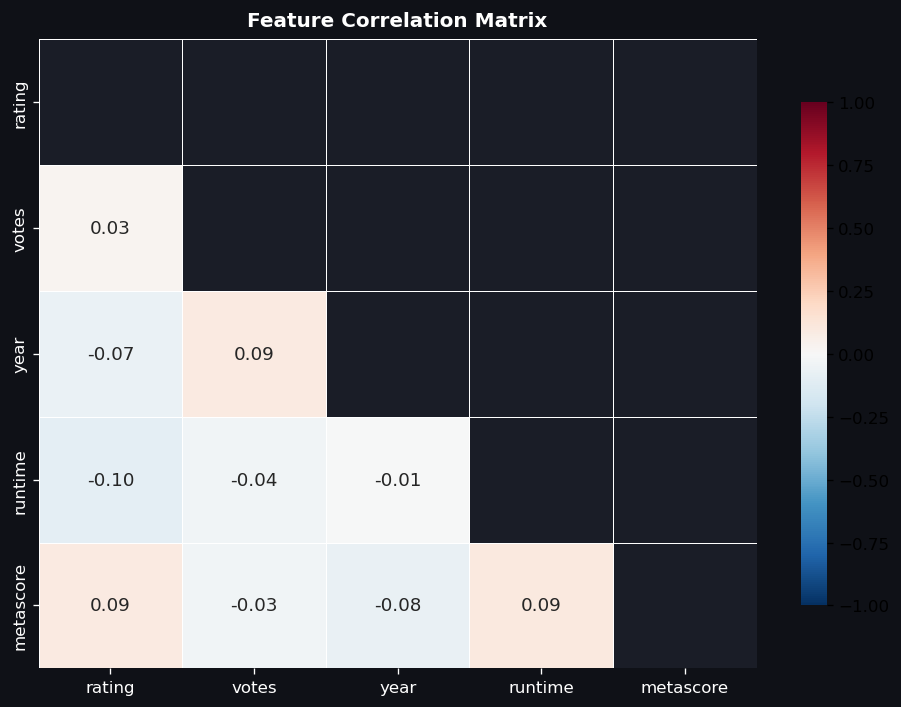


Pearson correlations with IMDb Rating:
metascore    0.088232
votes        0.029606
year        -0.067019
runtime     -0.099776


In [18]:
num_cols = [c for c in ['rating','votes','year','runtime','metascore'] if c in df.columns]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor(DARK_BG)
ax.set_facecolor(CARD_BG)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=ax, mask=mask, cmap='RdBu_r', vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 11},
            linewidths=0.4, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', color='white', fontsize=12, fontweight='bold', pad=8)
ax.tick_params(colors='white')
plt.tight_layout()
plt.show()

print('\nPearson correlations with IMDb Rating:')
print(corr['rating'].drop('rating').sort_values(ascending=False).to_string())

### 5.3 ANOVA — Does Genre Affect Rating?

One-way ANOVA   F = 0.738   p = 0.5958
→ No significant genre effect


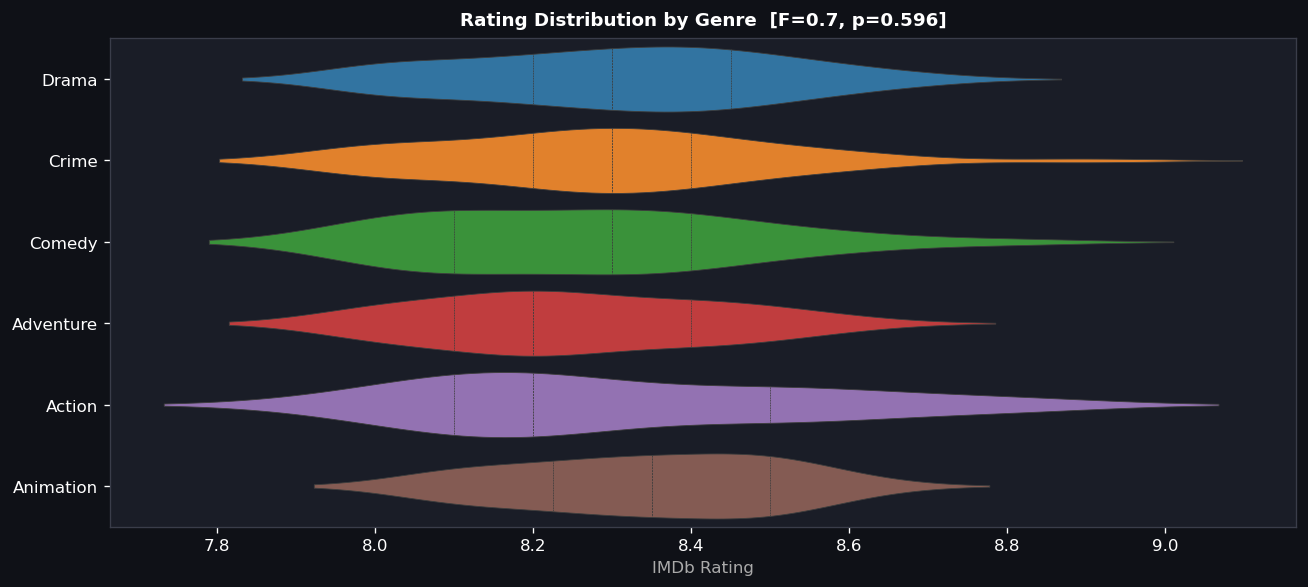

In [19]:
if 'primary_genre' in df.columns:
    top_g  = df['primary_genre'].value_counts().head(6).index
    groups = [df[df['primary_genre'] == g]['rating'].dropna() for g in top_g]
    f_stat, p_val = stats.f_oneway(*groups)
    print(f'One-way ANOVA   F = {f_stat:.3f}   p = {p_val:.4f}')
    print('→ Significant genre effect on rating' if p_val < 0.05
          else '→ No significant genre effect')

    fig, ax = plt.subplots(figsize=(11, 5))
    fig.patch.set_facecolor(DARK_BG)
    ax.set_facecolor(CARD_BG)
    sns.violinplot(data=df[df['primary_genre'].isin(top_g)],
                   x='rating', y='primary_genre',
                   order=top_g, palette='tab10', ax=ax,
                   inner='quartile', linewidth=0.5)
    ax.set_title(f'Rating Distribution by Genre  [F={f_stat:.1f}, p={"<0.001" if p_val<0.001 else f"{p_val:.3f}"}]',
                 color='white', fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('IMDb Rating', color='#AAAAAA')
    ax.set_ylabel('', color='#AAAAAA')
    ax.tick_params(colors='white')
    ax.spines[:].set_color('#3A3D4A')
    plt.tight_layout()
    plt.show()

### 5.4 Release Year vs Rating Trend

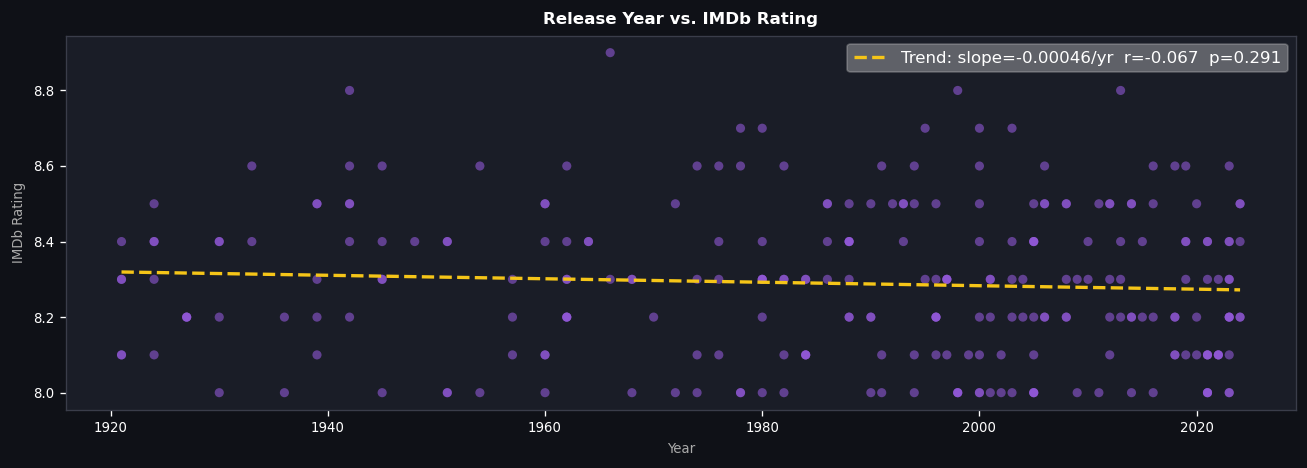

Interpretation: each decade, avg rating shifts by -0.005 points


In [20]:
fig, ax = plt.subplots(figsize=(11, 4))
fig.patch.set_facecolor(DARK_BG)
style_ax(ax, 'Release Year vs. IMDb Rating', 'Year', 'IMDb Rating')
ax.scatter(df['year'], df['rating'], color='#9B5DE5', alpha=0.55, s=30, edgecolors='none')
m, b, r, p, se = stats.linregress(df['year'].dropna(), df['rating'].dropna())
xs = np.linspace(df['year'].min(), df['year'].max(), 300)
ax.plot(xs, m*xs + b, color=ACCENT, lw=2, ls='--',
        label=f'Trend: slope={m:.5f}/yr  r={r:.3f}  p={"<0.001" if p<0.001 else f"{p:.3f}"}')
ax.legend(framealpha=0.3, labelcolor='white')
plt.tight_layout()
plt.show()
print(f'Interpretation: each decade, avg rating shifts by {m*10:+.3f} points')

## 6. Machine Learning: Predict IMDb Rating <a id='6-ml'></a>

We train **four models** to predict a film's IMDb rating from:

| Feature | Description |
|---|---|
| `year` | Release year |
| `runtime` | Film length (minutes) |
| `log_votes` | log₁₀ of audience vote count |
| `metascore` | Critic score (0–100) |
| `genre_enc` | Label-encoded primary genre |
| `decade` | Derived from year |


### 6.1 Feature Engineering & Train/Test Split

In [21]:
feats  = ['year', 'runtime', 'votes', 'metascore', 'primary_genre', 'decade']
feats  = [f for f in feats if f in df.columns]
target = 'rating'

ml_df = df[feats + [target]].dropna().copy()

# Log-transform votes
if 'votes' in ml_df.columns:
    ml_df['log_votes'] = np.log10(ml_df['votes'].clip(lower=1))
    feats = [f for f in feats if f != 'votes'] + ['log_votes']

# Encode genre
le = None
if 'primary_genre' in ml_df.columns:
    le = LabelEncoder()
    ml_df['genre_enc'] = le.fit_transform(ml_df['primary_genre'].astype(str))
    feats = [f for f in feats if f != 'primary_genre'] + ['genre_enc']

X = ml_df[feats]
y = ml_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler  = StandardScaler()
X_tr_s  = scaler.fit_transform(X_train)
X_te_s  = scaler.transform(X_test)

print(f'Train size: {len(X_train)}  |  Test size: {len(X_test)}')
print(f'Features : {feats}')

Train size: 200  |  Test size: 50
Features : ['year', 'runtime', 'metascore', 'decade', 'log_votes', 'genre_enc']


### 6.2 Train & Evaluate Models

In [22]:
models = {
    'Linear Regression':  LinearRegression(),
    'Ridge Regression':   Ridge(alpha=1.0),
    'Random Forest':      RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                                     learning_rate=0.05, random_state=42),
}

results = {}
for name, model in models.items():
    Xtr = X_tr_s if 'Regression' in name else X_train
    Xte = X_te_s if 'Regression' in name else X_test
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)
    cv    = cross_val_score(model, Xtr, y_train, cv=5, scoring='r2')
    results[name] = {
        'model': model, 'preds': preds,
        'MAE':  mean_absolute_error(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'R2':   r2_score(y_test, preds),
        'CV_mean': cv.mean(), 'CV_std': cv.std(),
    }

# Summary table
summary = pd.DataFrame([
    {'Model': n, 'MAE': v['MAE'], 'RMSE': v['RMSE'],
     'R²': v['R2'], 'CV R² (mean±std)': f"{v['CV_mean']:.3f} ± {v['CV_std']:.3f}"}
    for n, v in results.items()
]).set_index('Model').round(4)

summary

,MAE,RMSE,R²,CV R² (mean±std)
Model,,,,
Linear Regression,0.1852,0.2208,-0.2971,-0.068 ± 0.033
Ridge Regression,0.1852,0.2209,-0.2978,-0.064 ± 0.035
Random Forest,0.1935,0.2358,-0.4787,-0.144 ± 0.100
Gradient Boosting,0.2187,0.2608,-0.8090,-0.478 ± 0.175


### 6.3 Actual vs Predicted (per model)

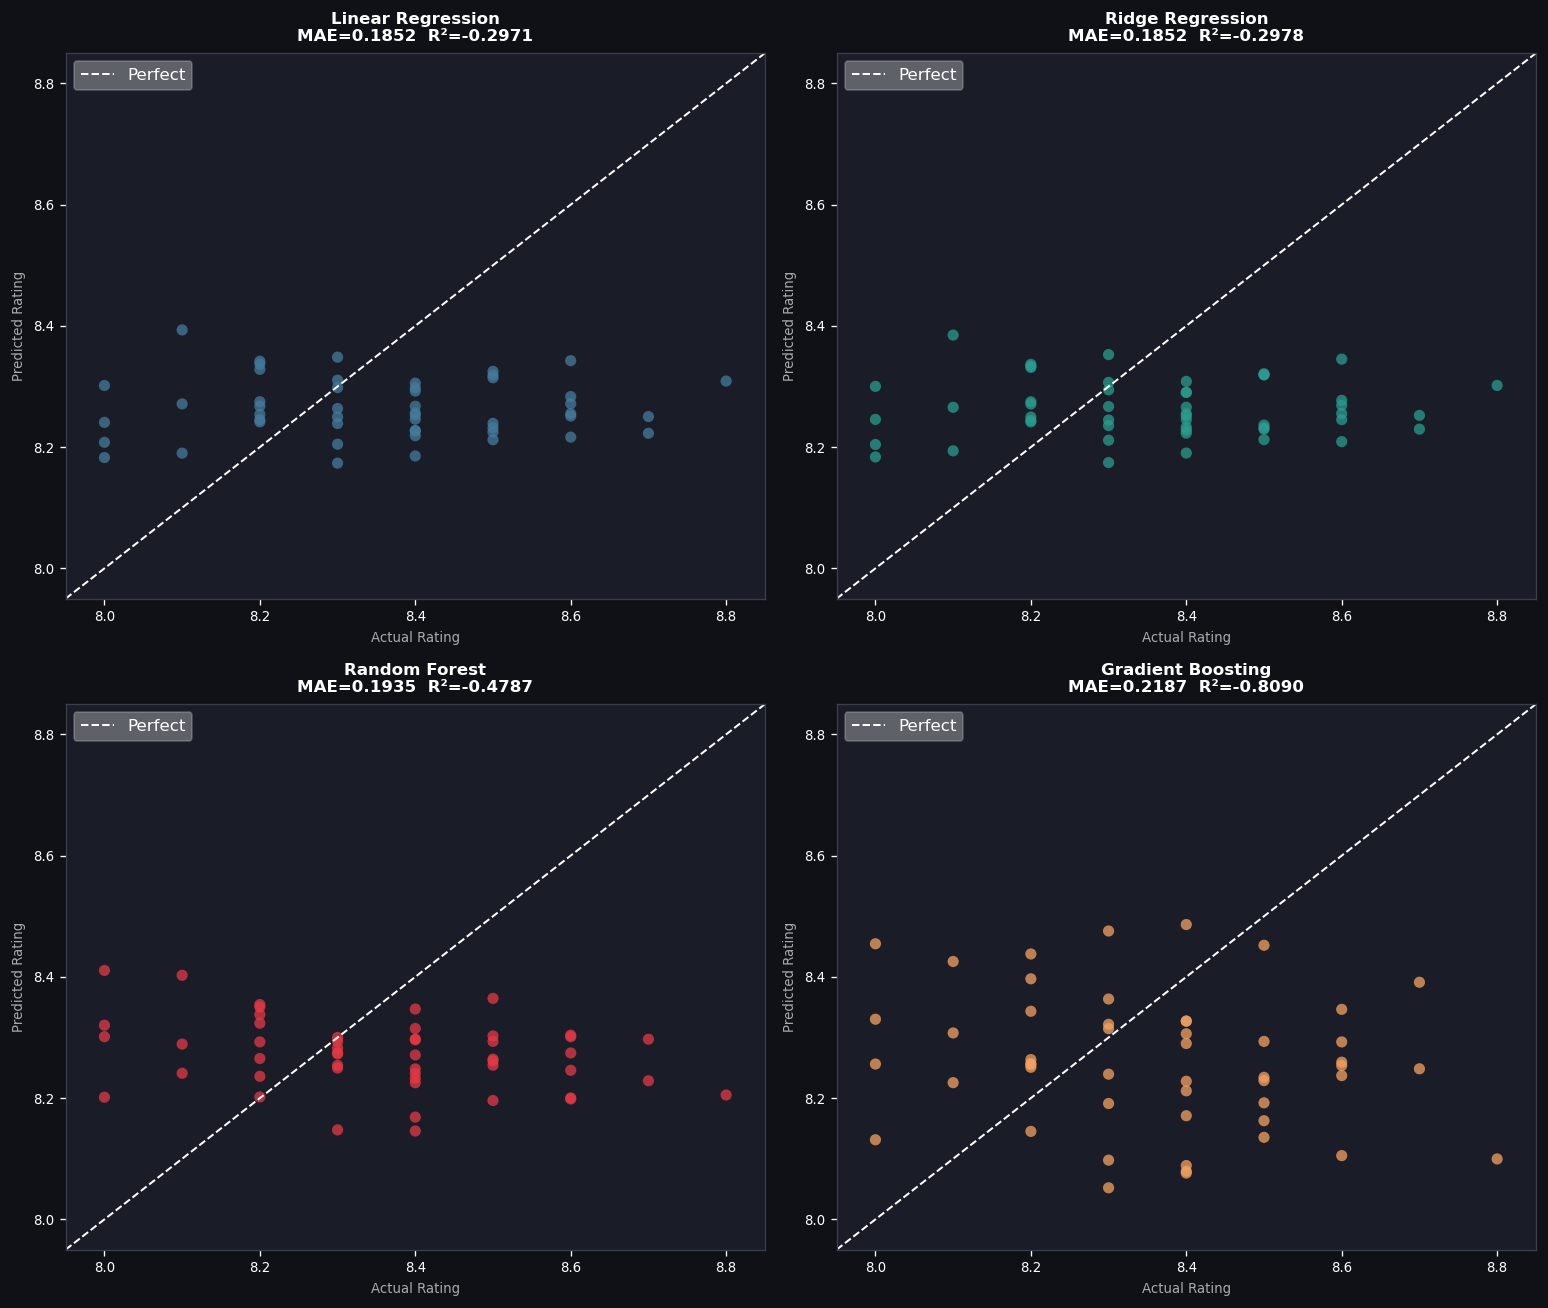

In [23]:
model_colors = ['#457B9D', '#2A9D8F', '#E63946', '#F4A261']
model_names  = list(results.keys())

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
fig.patch.set_facecolor(DARK_BG)

for ax, name, color in zip(axes.flat, model_names, model_colors):
    style_ax(ax,
             f"{name}\nMAE={results[name]['MAE']:.4f}  R²={results[name]['R2']:.4f}",
             'Actual Rating', 'Predicted Rating')
    preds = results[name]['preds']
    ax.scatter(y_test, preds, color=color, alpha=0.75, s=45, edgecolors='none')
    lo = min(y_test.min(), preds.min()) - 0.05
    hi = max(y_test.max(), preds.max()) + 0.05
    ax.plot([lo, hi], [lo, hi], color='white', lw=1.2, ls='--', label='Perfect')
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.legend(framealpha=0.3, labelcolor='white')

plt.tight_layout()
plt.show()

### 6.4 Model Comparison & Feature Importances

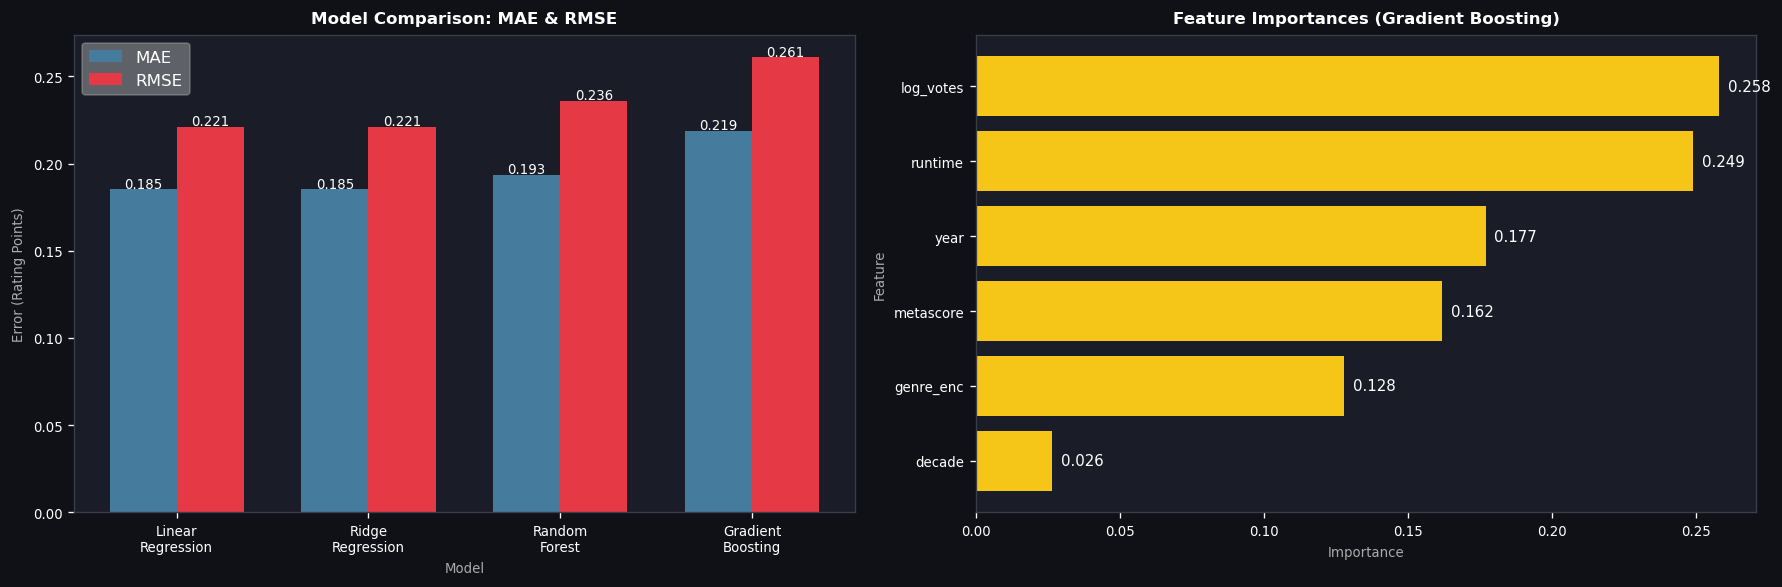

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor(DARK_BG)

# MAE / RMSE bar chart
ax = axes[0]
style_ax(ax, 'Model Comparison: MAE & RMSE', 'Model', 'Error (Rating Points)')
x = np.arange(len(model_names))
w = 0.35
mae_vals  = [results[n]['MAE']  for n in model_names]
rmse_vals = [results[n]['RMSE'] for n in model_names]
ax.bar(x - w/2, mae_vals,  w, label='MAE',  color='#457B9D', edgecolor='none')
ax.bar(x + w/2, rmse_vals, w, label='RMSE', color='#E63946', edgecolor='none')
ax.set_xticks(x)
ax.set_xticklabels([n.replace(' ', '\n') for n in model_names], fontsize=8)
ax.legend(framealpha=0.3, labelcolor='white')
for j, (m, r) in enumerate(zip(mae_vals, rmse_vals)):
    ax.text(j - w/2, m + 0.001, f'{m:.3f}', ha='center', color='white', fontsize=8)
    ax.text(j + w/2, r + 0.001, f'{r:.3f}', ha='center', color='white', fontsize=8)

# Feature importances (Gradient Boosting)
ax = axes[1]
style_ax(ax, 'Feature Importances (Gradient Boosting)', 'Importance', 'Feature')
feat_imp = pd.Series(results['Gradient Boosting']['model'].feature_importances_,
                     index=feats).sort_values(ascending=True)
ax.barh(feat_imp.index, feat_imp.values, color=ACCENT, edgecolor='none')
for j, (idx, val) in enumerate(feat_imp.items()):
    ax.text(val + 0.003, j, f'{val:.3f}', va='center', color='white', fontsize=9)

plt.tight_layout()
plt.show()

## 7. Trend Forecasting <a id='7-forecast'></a>

### 7.1 Average Rating Trend + Forecast to 2030

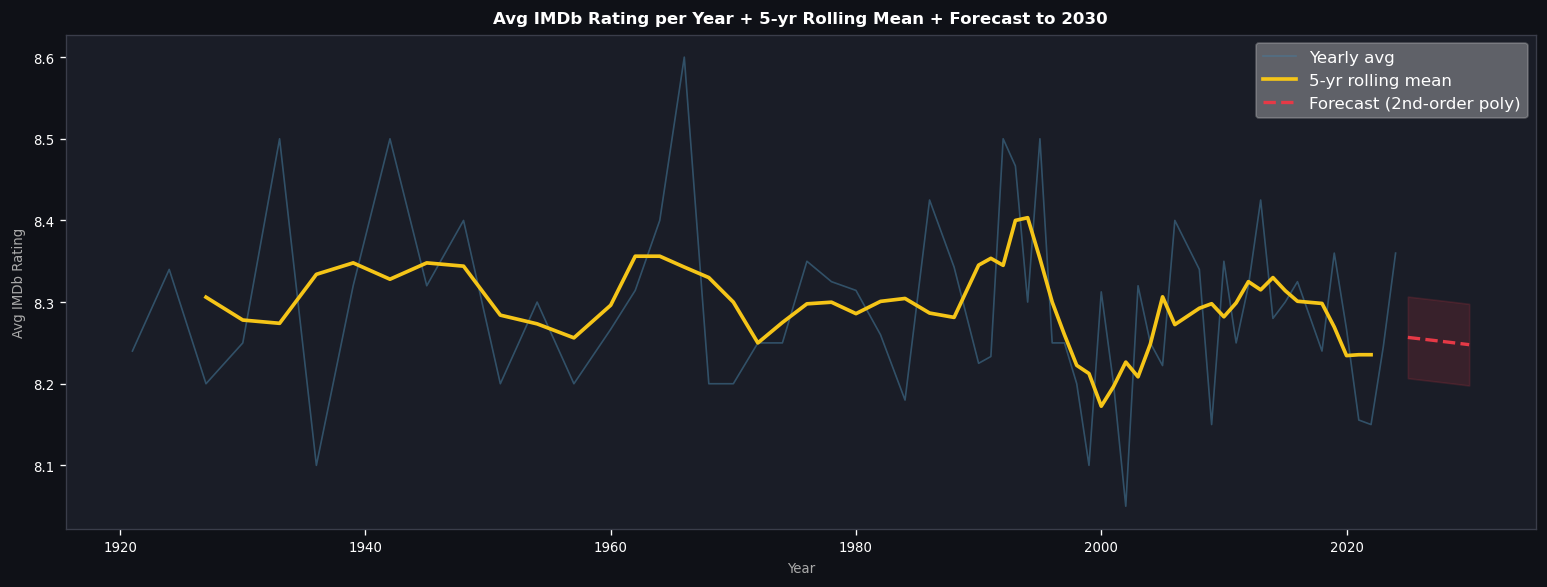

Forecast values 2025–2030:
  2025: 8.257
  2026: 8.255
  2027: 8.253
  2028: 8.251
  2029: 8.250
  2030: 8.248


In [25]:
fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor(DARK_BG)
style_ax(ax, 'Avg IMDb Rating per Year + 5-yr Rolling Mean + Forecast to 2030',
         'Year', 'Avg IMDb Rating')

yr_avg  = df.groupby('year')['rating'].mean()
rolling = yr_avg.rolling(5, center=True).mean()

ax.plot(yr_avg.index, yr_avg.values,   color='#457B9D', lw=1.0, alpha=0.55, label='Yearly avg')
ax.plot(rolling.index, rolling.values, color=ACCENT,    lw=2.2, label='5-yr rolling mean')

# Polynomial forecast
valid  = yr_avg.dropna()
coeffs = np.polyfit(valid.index, valid.values, deg=2)
poly   = np.poly1d(coeffs)
xf     = np.arange(valid.index.max() + 1, 2031)
ax.plot(xf, poly(xf), color='#E63946', lw=2, ls='--', label='Forecast (2nd-order poly)')
ax.fill_between(xf, poly(xf) - 0.05, poly(xf) + 0.05, color='#E63946', alpha=0.15)
ax.legend(framealpha=0.3, labelcolor='white')
plt.tight_layout()
plt.show()

print('Forecast values 2025–2030:')
for yr in range(2025, 2031):
    print(f'  {yr}: {poly(yr):.3f}')

### 7.2 Audience Engagement (Votes) over Time

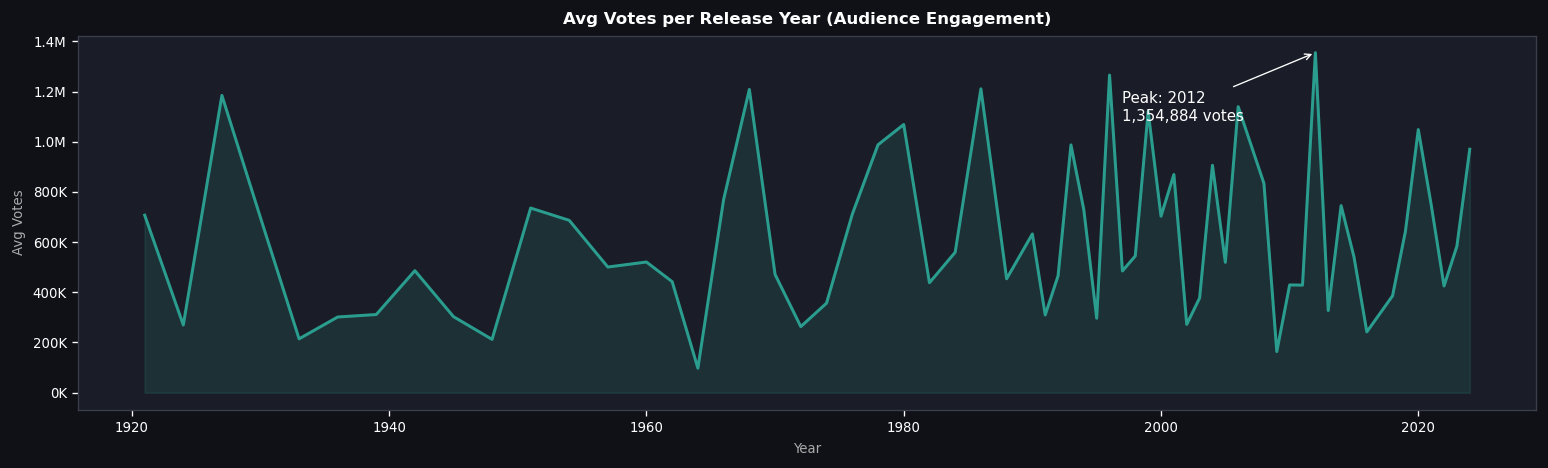

In [26]:
if 'votes' in df.columns:
    fig, ax = plt.subplots(figsize=(13, 4))
    fig.patch.set_facecolor(DARK_BG)
    style_ax(ax, 'Avg Votes per Release Year (Audience Engagement)', 'Year', 'Avg Votes')
    vt = df.groupby('year')['votes'].mean()
    ax.plot(vt.index, vt.values, color='#2A9D8F', lw=1.8)
    ax.fill_between(vt.index, vt.values, alpha=0.15, color='#2A9D8F')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))
    peak_yr = vt.idxmax()
    ax.annotate(f'Peak: {peak_yr}\n{vt[peak_yr]:,.0f} votes',
                xy=(peak_yr, vt[peak_yr]),
                xytext=(peak_yr - 15, vt[peak_yr] * 0.8),
                color='white', fontsize=9,
                arrowprops=dict(arrowstyle='->', color='white', lw=0.8))
    plt.tight_layout()
    plt.show()

### 7.3 Genre Dominance Shift by Decade

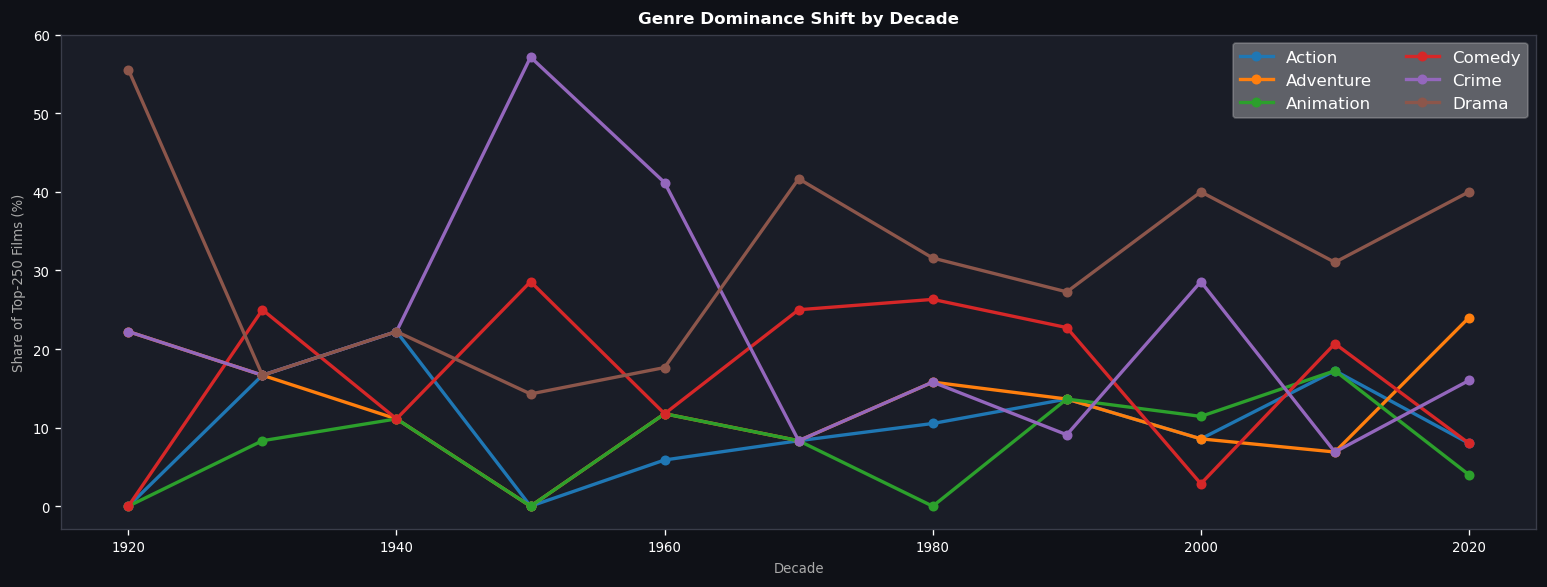

In [27]:
if 'primary_genre' in df.columns:
    top_g  = df['primary_genre'].value_counts().head(6).index
    gd     = (df[df['primary_genre'].isin(top_g)]
               .groupby(['decade','primary_genre']).size()
               .unstack(fill_value=0))
    gd_pct = gd.div(gd.sum(axis=1), axis=0) * 100

    fig, ax = plt.subplots(figsize=(13, 5))
    fig.patch.set_facecolor(DARK_BG)
    style_ax(ax, 'Genre Dominance Shift by Decade', 'Decade', 'Share of Top-250 Films (%)')
    for genre in gd_pct.columns:
        ax.plot(gd_pct.index, gd_pct[genre], marker='o', lw=2, markersize=5, label=genre)
    ax.legend(loc='upper right', framealpha=0.3, labelcolor='white', ncol=2)
    plt.tight_layout()
    plt.show()

### 7.4 Residuals — Over / Under-Rated Movies

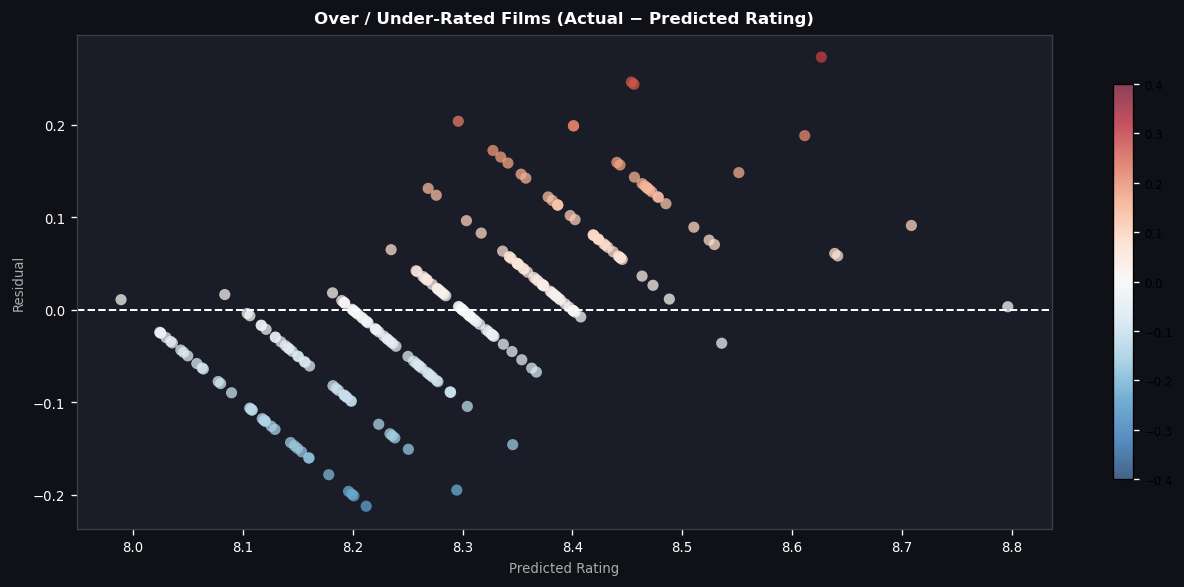

Most OVER-rated (actual > predicted):
     title  year  rating  predicted  residual
 Movie #85  1966     8.9   8.626819  0.273181
Movie #188  2000     8.7   8.453805  0.246195
Movie #162  1995     8.7   8.456087  0.243913
 Movie #74  1972     8.5   8.296130  0.203870
Movie #248  2018     8.6   8.400965  0.199035

Most UNDER-rated (actual < predicted):
     title  year  rating  predicted  residual
 Movie #72  2014     8.0   8.212240 -0.212240
Movie #125  1982     8.0   8.200985 -0.200985
Movie #233  1972     8.0   8.199189 -0.199189
Movie #156  2002     8.0   8.196210 -0.196210
Movie #206  1991     8.1   8.294765 -0.194765


In [28]:
# Refit Gradient Boosting on full dataset to get residuals for all films
res_feats = ['year', 'runtime', 'log_votes', 'metascore', 'genre_enc', 'decade']
res_df    = df.dropna(subset=['year','runtime','votes','metascore','rating']).copy()

if 'primary_genre' in res_df.columns:
    le2 = LabelEncoder()
    res_df['genre_enc'] = le2.fit_transform(res_df['primary_genre'].astype(str))
res_df['log_votes'] = np.log10(res_df['votes'].clip(lower=1))

rf_avail = [f for f in res_feats if f in res_df.columns]
gb_full  = GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                      learning_rate=0.05, random_state=42)
gb_full.fit(res_df[rf_avail], res_df['rating'])
res_df['predicted'] = gb_full.predict(res_df[rf_avail])
res_df['residual']  = res_df['rating'] - res_df['predicted']

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor(DARK_BG)
style_ax(ax, 'Over / Under-Rated Films (Actual − Predicted Rating)',
         'Predicted Rating', 'Residual')
sc = ax.scatter(res_df['predicted'], res_df['residual'],
                c=res_df['residual'], cmap='RdBu_r', vmin=-0.4, vmax=0.4,
                alpha=0.75, s=45, edgecolors='none')
ax.axhline(0, color='white', lw=1.2, ls='--')
plt.colorbar(sc, ax=ax, shrink=0.8).ax.yaxis.set_tick_params(color='white', labelsize=7)
plt.tight_layout()
plt.show()

print('Most OVER-rated (actual > predicted):')
print(res_df.nlargest(5, 'residual')[['title','year','rating','predicted','residual']].to_string(index=False))
print('\nMost UNDER-rated (actual < predicted):')
print(res_df.nsmallest(5, 'residual')[['title','year','rating','predicted','residual']].to_string(index=False))

## 8. Key Insights Summary <a id='8-insights'></a>

In [30]:
print('=' * 60)
print('  IMDB TOP 250 — KEY INSIGHTS')
print('=' * 60)

print(f"\n📊 Dataset: {len(df)} films  |  {df['year'].min():.0f}–{df['year'].max():.0f}")
print(f"⭐ Rating range: {df['rating'].min():.1f} – {df['rating'].max():.1f}  (mean {df['rating'].mean():.2f})")

if 'votes' in df.columns:
    print(f"👥 Avg votes: {df['votes'].mean():,.0f}  |  Max: {df['votes'].max():,.0f}")

if 'runtime' in df.columns:
    print(f"⏱  Avg runtime: {df['runtime'].mean():.0f} min")

if 'primary_genre' in df.columns:
    top_genre = df['primary_genre'].value_counts().idxmax()
    top_cnt   = df['primary_genre'].value_counts().max()
    print(f"🎭 Most common genre: {top_genre} ({top_cnt} films)")

if 'director' in df.columns:
    top_dir = df['director'].value_counts().idxmax()
    top_dir_cnt = df['director'].value_counts().max()
    print(f"🎬 Most represented director: {top_dir} ({top_dir_cnt} films)")

best_model = min(results, key=lambda n: results[n]['MAE'])
print(f"\n🤖 Best ML model: {best_model}")
print(f"   MAE  = {results[best_model]['MAE']:.4f}")
print(f"   RMSE = {results[best_model]['RMSE']:.4f}")
print(f"   R²   = {results[best_model]['R2']:.4f}")

  IMDB TOP 250 — KEY INSIGHTS

📊 Dataset: 250 films  |  1921–2024
⭐ Rating range: 8.0 – 8.9  (mean 8.29)
👥 Avg votes: 642,361  |  Max: 2,800,000
⏱  Avg runtime: 128 min
🎭 Most common genre: Drama (63 films)
🎬 Most represented director: Peter Jackson (21 films)

🤖 Best ML model: Ridge Regression
   MAE  = 0.1852
   RMSE = 0.2209
   R²   = -0.2978
